# Results

This notebook presents the results of the experiments conducted on the top tagging task. All the runs use the dataset with the invariant mass cut ($145$ to $205$ GeV) and the split into 5 mutually disjoint subsets. Each seed (10, 11, 12, 13, and 14) trains and evaluates all the models on its own subset, so the 5 seeds work as statistical replicates.

All the runs analyzed here can be reproduced with `scripts/reproduce_results.sh`. Without flags, it runs the full pipeline for the seeds 10, 11, 12, 13, and 14 with the mass cut and the 5 subsets: preprocessing, classic KAN, QKAN with the KAN warm start, QKAN with random initialization, Random Forest, the comparison of the untrained Chebyshev, sine, and random initializations, and finally the two collection scripts. The script runs in the background with `nohup` and writes its progress to a log file.

Once the runs exist, the first step is to collect the metrics. For that we use the `collect_metrics.py` script, which gathers all the per-run/per-model metrics JSON files into a single Parquet table, and the `collect_eval_data.py` script, which gathers the per-event predictions and the training histories into a second table.

In [1]:
# Reproduce the 5 seeds analyzed here (10-14, mass cut, 5 subsets); the script also runs both collection scripts below
#!bash ../scripts/reproduce_results.sh

# Collect metrics and per-event evaluation data for the "top" task
#!python3 ../scripts/collect_metrics.py --task top
#!python3 ../scripts/collect_eval_data.py --task top

Now we import the libraries used in this notebook.

In [2]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from scipy.stats import ttest_rel
from sklearn.metrics import roc_curve

sys.path.append(str(Path.cwd().parent))  # repo root, so `src` resolves from notebooks/
from src.utils.workspace import get_config
from src.utils.hyperparams import TOTAL_FEATURES
print("All libraries imported successfully")

All libraries imported successfully


First, let's see the structure of the dataset. We keep only the runs with the invariant mass cut and the 5 subsets.

In [4]:
# task-level metrics table written by scripts/collect_metrics.py
config = get_config("top", 10)
df = pd.read_parquet(config["metrics_table_path"], engine="pyarrow")

# keep only the mass-cut runs split into 5 subsets (one seed per subset)
df = df[df["apply_mass_cut"] & (df["n_subsets"] == 5)].reset_index(drop=True)
SEEDS = sorted(df["seed"].unique())
print("Seeds:", SEEDS)
df.columns

Seeds: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]


Index(['task', 'seed', 'variant', 'apply_mass_cut', 'n_subsets', 'subset_id',
       'model', 'Test Loss', 'Test Accuracy', 'Test F1 Score', 'Test AUC',
       'Test Precision', 'Test Recall', 'Confusion Matrix',
       'Sig Eff 0.3 - Achieved Sig Eff', 'Sig Eff 0.3 - Bkg Eff',
       'Sig Eff 0.3 - Bkg Rejection', 'Sig Eff 0.5 - Achieved Sig Eff',
       'Sig Eff 0.5 - Bkg Eff', 'Sig Eff 0.5 - Bkg Rejection',
       'Sig Eff 0.7 - Achieved Sig Eff', 'Sig Eff 0.7 - Bkg Eff',
       'Sig Eff 0.7 - Bkg Rejection', 'Sig Eff 0.9 - Achieved Sig Eff',
       'Sig Eff 0.9 - Bkg Eff', 'Sig Eff 0.9 - Bkg Rejection',
       'total_pipeline_time_seconds', 'Backend', 'Baseline', 'Random Init',
       'Eval Time (s)', 'Sine Basis'],
      dtype='str')

This shows the first 10 rows of the dataset.

In [5]:
df.head(10)

,task,seed,variant,apply_mass_cut,n_subsets,subset_id,model,Test Loss,Test Accuracy,Test F1 Score,...,Sig Eff 0.7 - Bkg Rejection,Sig Eff 0.9 - Achieved Sig Eff,Sig Eff 0.9 - Bkg Eff,Sig Eff 0.9 - Bkg Rejection,total_pipeline_time_seconds,Backend,Baseline,Random Init,Eval Time (s),Sine Basis
0,top,10,mass_cut/n5_subset0,True,5,0,classical_base,0.550835,0.717515,0.730498,...,3.768312,0.900063,0.531587,1.881161,NaN,NaN,None,None,NaN,None
1,top,10,mass_cut/n5_subset0,True,5,0,classical_retrained,0.579229,0.692373,0.701762,...,3.180780,0.900275,0.577224,1.732430,NaN,NaN,None,None,NaN,None
2,top,10,mass_cut/n5_subset0,True,5,0,classical_symbolic,0.579559,0.692056,0.701973,...,3.178643,0.900063,0.578280,1.729266,NaN,NaN,None,None,NaN,None
3,top,10,mass_cut/n5_subset0,True,5,0,classical_final,0.555729,0.712445,0.727473,...,3.717989,0.900909,0.547433,1.826708,381.052549,NaN,None,None,NaN,None
4,top,10,mass_cut/n5_subset0,True,5,0,qkan_ideal,0.660295,0.555356,0.687690,...,2.692264,0.900275,0.636594,1.570860,NaN,ideal,False,False,148.395615,None
5,top,10,mass_cut/n5_subset0,True,5,0,qkan_noisy,0.662359,0.557680,0.685637,...,2.660483,0.902387,0.685823,1.458102,NaN,noisy,False,False,3241.544209,None
6,top,10,mass_cut/n5_subset0,True,5,0,qkan_shots,0.660307,0.559899,0.687378,...,2.635301,0.900275,0.664906,1.503972,NaN,shots,False,False,84.071893,None
7,top,10,mass_cut/n5_subset0,True,5,0,qkan_baseline_ideal,0.667395,0.549123,0.684179,...,2.336130,0.900486,0.707585,1.413258,NaN,ideal,True,False,144.964824,None
8,top,10,mass_cut/n5_subset0,True,5,0,qkan_sine_baseline_ideal,0.683192,0.527572,0.674100,...,1.898516,0.901542,0.758082,1.319119,NaN,ideal,True,False,153.145629,True
9,top,10,mass_cut/n5_subset0,True,5,0,qkan_baseline_random_ideal,0.693138,0.482252,0.462079,...,1.437291,0.900063,0.896683,1.115221,NaN,ideal,True,True,151.834562,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   task                            65 non-null     str    
 1   seed                            65 non-null     int64  
 2   variant                         65 non-null     str    
 3   apply_mass_cut                  65 non-null     bool   
 4   n_subsets                       65 non-null     int64  
 5   subset_id                       65 non-null     int64  
 6   model                           65 non-null     str    
 7   Test Loss                       65 non-null     float64
 8   Test Accuracy                   65 non-null     float64
 9   Test F1 Score                   65 non-null     float64
 10  Test AUC                        65 non-null     float64
 11  Test Precision                  65 non-null     float64
 12  Test Recall                     65 non-null     f

We also define display names and a fixed order for the models, used in every plot of this notebook.

In [7]:
# display names and a fixed order used in every plot
MODEL_LABELS = {
    "random_forest": "Random Forest",
    "classical_base": "KAN base",
    "classical_retrained": "KAN retrained",
    "classical_symbolic": "KAN symbolic",
    "classical_final": "KAN final",
    "qkan_ideal": "QKAN trained (ideal)",
    "qkan_shots": "QKAN trained (shots)",
    "qkan_noisy": "QKAN trained (noisy)",
    "qkan_baseline_ideal": "QKAN Chebyshev init (ideal)",
    "qkan_baseline_shots": "QKAN Chebyshev init (shots)",
    "qkan_baseline_noisy": "QKAN Chebyshev init (noisy)",
    "qkan_sine_baseline_ideal": "QKAN sine init (ideal)",
    "qkan_baseline_random_ideal": "QKAN random init (ideal)",
}
MODEL_ORDER = list(MODEL_LABELS)

## Mass cut and subset results

Now let's see the statistical summary of the metrics, grouped by the `model` column, over the seeds 10, 11, 12, 13, and 14.

In [8]:
# statistical description of the dataset by 'model'
metrics = ['Test Loss', 'Test F1 Score']

df[['model', *metrics]].groupby('model')[metrics].describe()

Test Loss                                          \
                               count      mean       std       min       25%   
model                                                                          
classical_base                   5.0  0.553535  0.002095  0.550835  0.552252   
classical_final                  5.0  0.572881  0.014274  0.555729  0.561493   
classical_retrained              5.0  0.582835  0.002951  0.579229  0.580190   
classical_symbolic               5.0  0.583100  0.002878  0.579559  0.580517   
qkan_baseline_ideal              5.0  0.669224  0.001285  0.667395  0.668580   
qkan_baseline_noisy              5.0  0.670483  0.001127  0.668883  0.669863   
qkan_baseline_random_ideal       5.0  0.693145  0.000038  0.693104  0.693115   
qkan_baseline_shots              5.0  0.669271  0.001266  0.667525  0.668623   
qkan_ideal                       5.0  0.658255  0.001882  0.655724  0.657125   
qkan_noisy                       5.0  0.660307  0.001815  0.657846  0.659187   
qkan_shots                       5.0  0.658336  0.001866  0.655869  0.657096   
qkan_sine_baseline_ideal         5.0  0.682232  0.001072  0.680802  0.681375   
random_forest                    5.0  0.523097  0.003020  0.519699  0.521398   

                                                         Test F1 Score  \
                                 50%       75%       max         count   
model                                                                    
classical_base              0.553452  0.555142  0.555992           5.0   
classical_final             0.577905  0.577952  0.591326           5.0   
classical_retrained         0.584089  0.584703  0.585963           5.0   
classical_symbolic          0.584181  0.585469  0.585772           5.0   
qkan_baseline_ideal         0.669592  0.669784  0.670771           5.0   
qkan_baseline_noisy         0.670653  0.671460  0.671556           5.0   
qkan_baseline_random_ideal  0.693138  0.693178  0.693189           5.0   
qkan_baseline_shots         0.669577  0.669735  0.670895           5.0   
qkan_ideal                  0.658352  0.659776  0.660295           5.0   
qkan_noisy                  0.660579  0.661566  0.662359           5.0   
qkan_shots                  0.658532  0.659877  0.660307           5.0   
qkan_sine_baseline_ideal    0.682807  0.682986  0.683192           5.0   
random_forest               0.522768  0.523908  0.527710           5.0   

                                                                              \
                                mean       std       min       25%       50%   
model                                                                          
classical_base              0.727555  0.004357  0.720539  0.726103  0.729727   
classical_final             0.696847  0.027467  0.658285  0.680637  0.704539   
classical_retrained         0.698695  0.007134  0.687001  0.697141  0.701762   
classical_symbolic          0.699234  0.006740  0.689065  0.695898  0.701973   
qkan_baseline_ideal         0.683935  0.003138  0.679838  0.681961  0.684179   
qkan_baseline_noisy         0.678926  0.000750  0.677881  0.678464  0.679094   
qkan_baseline_random_ideal  0.493276  0.028554  0.462079  0.474025  0.488861   
qkan_baseline_shots         0.678836  0.002584  0.675307  0.677917  0.678946   
qkan_ideal                  0.690004  0.003731  0.686769  0.687690  0.688076   
qkan_noisy                  0.689870  0.006535  0.685210  0.685637  0.686796   
qkan_shots                  0.690196  0.005494  0.685645  0.686741  0.687378   
qkan_sine_baseline_ideal    0.665939  0.013041  0.650585  0.653227  0.672864   
random_forest               0.746478  0.004768  0.738660  0.745845  0.748077   

                                                
                                 75%       max  
model                                           
classical_base              0.730498  0.730907  
classical_final             0.713301  0.727473  
classical_retrained         0.70252

In [9]:
# statistical description of the dataset by 'model'
metrics = ['Test Accuracy', 'Test AUC']

df[['model', *metrics]].groupby('model')[metrics].describe()

Test Accuracy                                \
                                   count      mean       std       min   
model                                                                    
classical_base                       5.0  0.712445  0.003722  0.707585   
classical_final                      5.0  0.696260  0.013237  0.678428   
classical_retrained                  5.0  0.687302  0.005289  0.681280   
classical_symbolic                   5.0  0.687070  0.005098  0.681280   
qkan_baseline_ideal                  5.0  0.550835  0.015165  0.532643   
qkan_baseline_noisy                  5.0  0.547243  0.007722  0.538770   
qkan_baseline_random_ideal           5.0  0.492373  0.013620  0.476970   
qkan_baseline_shots                  5.0  0.546123  0.010046  0.534228   
qkan_ideal                           5.0  0.562899  0.012594  0.550074   
qkan_noisy                           5.0  0.570759  0.016067  0.557680   
qkan_shots                           5.0  0.570970  0.014545  0.559899   
qkan_sine_baseline_ideal             5.0  0.531016  0.007787  0.520389   
random_forest                        5.0  0.746355  0.004044  0.739489   

                                                                   Test AUC  \
                                 25%       50%       75%       max    count   
model                                                                         
classical_base              0.710649  0.712339  0.714135  0.717515      5.0   
classical_final             0.690894  0.693957  0.705578  0.712445      5.0   
classical_retrained         0.682231  0.688570  0.692056  0.692373      5.0   
classical_symbolic          0.682020  0.688781  0.691211  0.692056      5.0   
qkan_baseline_ideal         0.540144  0.549123  0.564758  0.567505      5.0   
qkan_baseline_noisy         0.540778  0.547010  0.552609  0.557046      5.0   
qkan_baseline_random_ideal  0.482252  0.491020  0.501373  0.510247      5.0   
qkan_baseline_shots         0.537820  0.547750  0.552398  0.558420      5.0   
qkan_ideal                  0.555356  0.556729  0.572787  0.579548      5.0   
qkan_noisy                  0.558842  0.564969  0.575850  0.596450      5.0   
qkan_shots                  0.561378  0.561483  0.579442  0.592647      5.0   
qkan_sine_baseline_ideal    0.527572  0.530213  0.536658  0.540249      5.0   
random_forest               0.746355  0.747412  0.748891  0.749630      5.0   

                                                                              \
                                mean       std       min       25%       50%   
model                                                                          
classical_base              0.788842  0.002421  0.786331  0.787194  0.787867   
classical_final             0.770097  0.014252  0.752274  0.762546  0.767211   
classical_retrained         0.756040  0.003965  0.751386  0.753633  0.754951   
classical_symbolic          0.755626  0.004066  0.751391  0.752308  0.754784   
qkan_baseline_ideal         0.698297  0.003717  0.691926  0.698769  0.698915   
qkan_baseline_noisy         0.693142  0.002527  0.689275  0.692373  0.693459   
qkan_baseline_random_ideal  0.488003  0.021487  0.456445  0.475158  0.499083   
qkan_baseline_shots         0.693989  0.003660  0.687830  0.694456  0.694972   
qkan_ideal                  0.736154  0.005584  0.730117  0.731077  0.736260   
qkan_noisy                  0.729908  0.005765  0.723503  0.724006  0.732241   
qkan_shots                  0.731508  0.005810  0.724160  0.726489  0.733831   
qkan_sine_baseline_ideal    0.637122  0.014637  0.623078  0.625541  0.631856   
random_forest               0.822900  0.003722  0.817380  0.822067  0.822412   

                                                
                                 75%       max  
model                                           
classical_base              0.791036  0.791784  
classical_final             0.780336  0.788116  
classical_retrained         0.759395  0.760834  
cl

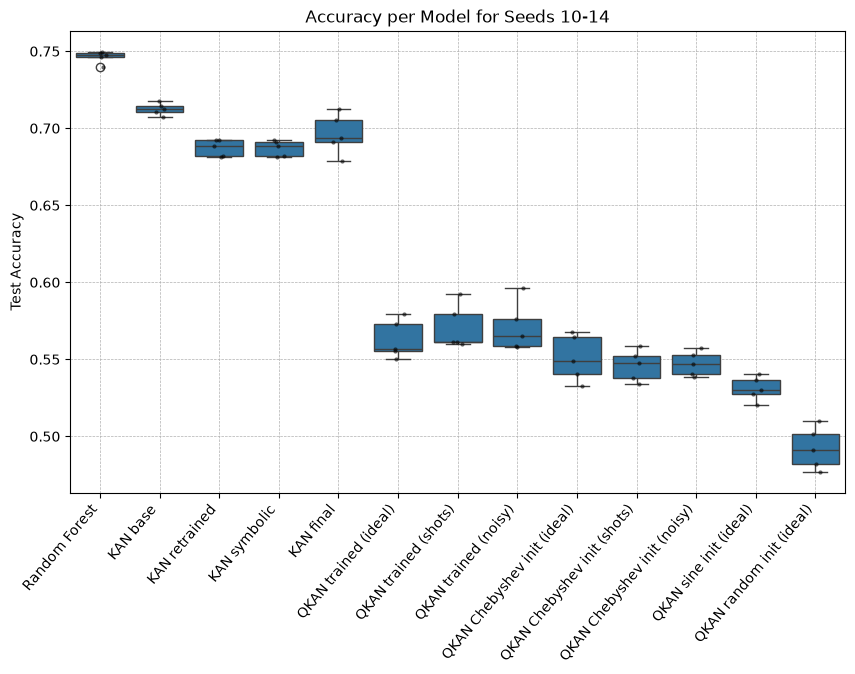

In [10]:
# accuracy per model across the 5 seeds
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='Test Accuracy', data=df, order=MODEL_ORDER)
sns.stripplot(x='model', y='Test Accuracy', data=df, order=MODEL_ORDER, color='black', size=3, alpha=0.6)
plt.title('Accuracy per Model for Seeds 10-14')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(len(MODEL_ORDER)), [MODEL_LABELS[m] for m in MODEL_ORDER], rotation=50, ha='right')
plt.xlabel('')
plt.show()

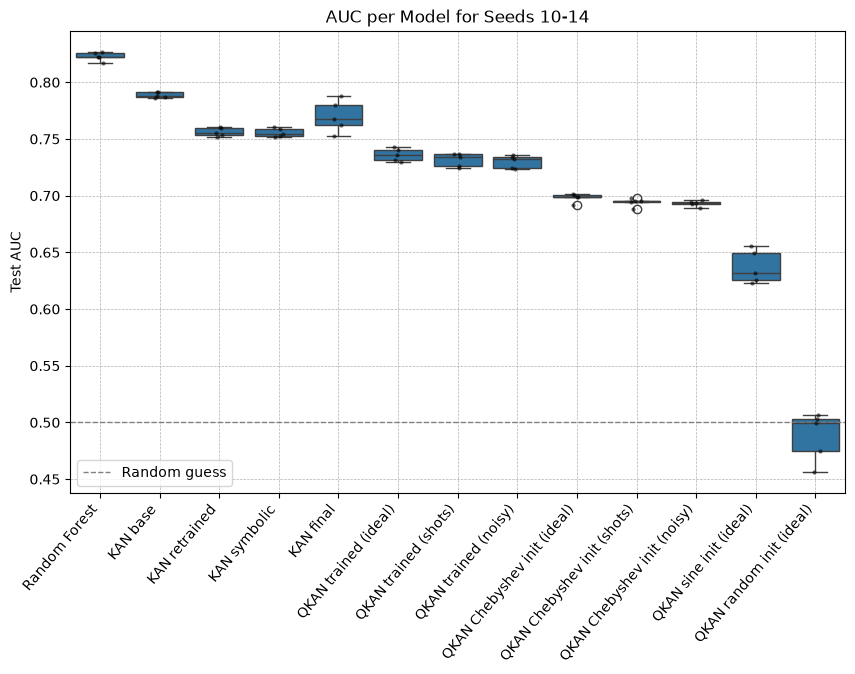

In [11]:
# AUC per model across the 5 seeds
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='Test AUC', data=df, order=MODEL_ORDER)
sns.stripplot(x='model', y='Test AUC', data=df, order=MODEL_ORDER, color='black', size=3, alpha=0.6)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random guess')
plt.title('AUC per Model for Seeds 10-14')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(len(MODEL_ORDER)), [MODEL_LABELS[m] for m in MODEL_ORDER], rotation=50, ha='right')
plt.xlabel('')
plt.legend(loc='lower left')
plt.show()

/tmp/ipykernel_71164/1999461429.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_71164/1999461429.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


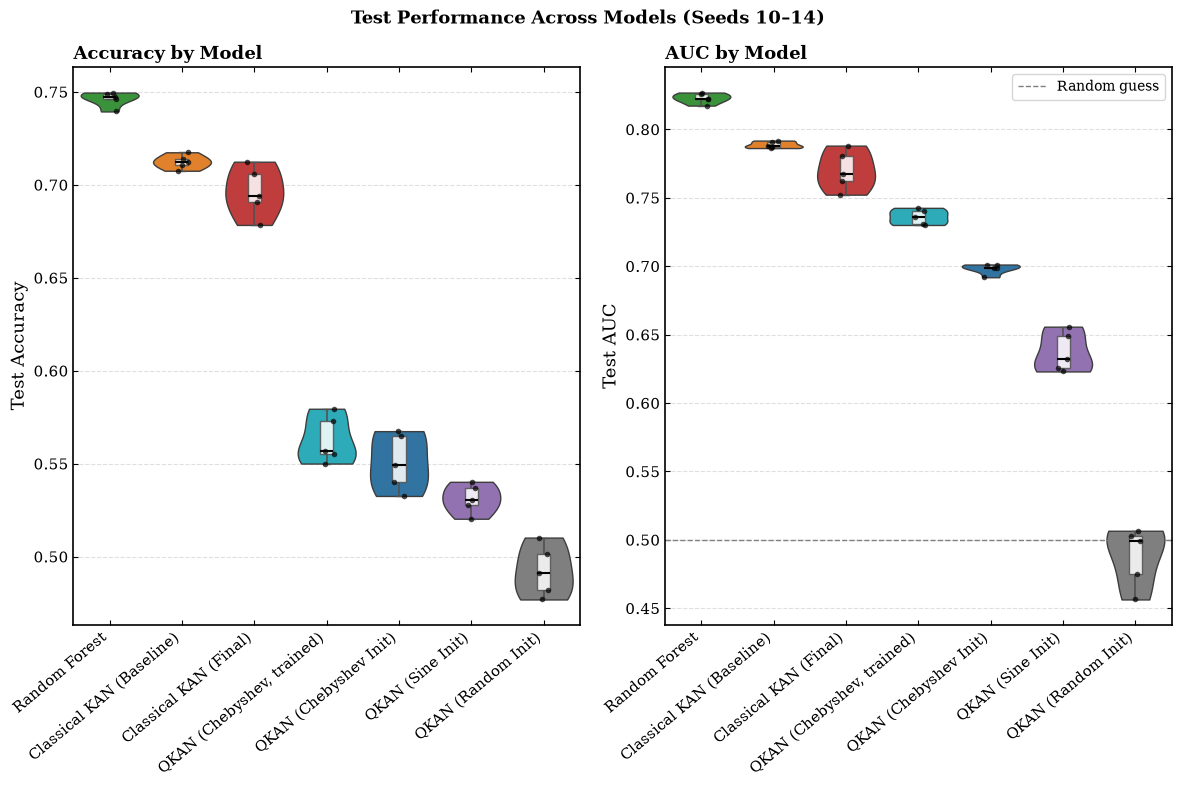

In [30]:
models = {
    'random_forest': {'label': 'Random Forest', 'color': '#2ca02c', 'linestyle': '-'},
    'classical_base': {'label': 'Classical KAN (Baseline)', 'color': '#ff7f0e', 'linestyle': '-'},
    'classical_final': {'label': 'Classical KAN (Final)', 'color': '#d62728', 'linestyle': '--'},
    'qkan_ideal': {'label': 'QKAN (Chebyshev, trained)', 'color': '#17becf', 'linestyle': '--'},
    'qkan_baseline_ideal': {'label': 'QKAN (Chebyshev Init)', 'color': '#1f77b4', 'linestyle': '-'},
    'qkan_sine_baseline_ideal': {'label': 'QKAN (Sine Init)', 'color': '#9467bd', 'linestyle': '-'},
    'qkan_baseline_random_ideal': {'label': 'QKAN (Random Init)', 'color': '#7f7f7f', 'linestyle': '-'},
}

model_order = list(models)
display_order = [models[model]["label"] for model in model_order]
palette = {
    models[model]["label"]: models[model]["color"]
    for model in model_order
}

plot_df = df[df["model"].isin(model_order)].copy()
plot_df["Model"] = plot_df["model"].map(
    {model: models[model]["label"] for model in model_order}
)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for ax, metric, title in zip(
    axes,
    ["Test Accuracy", "Test AUC"],
    ["Accuracy by Model", "AUC by Model"],
):
    sns.violinplot(
        data=plot_df,
        x="Model",
        y=metric,
        order=display_order,
        palette=palette,
        inner=None,
        cut=0,
        linewidth=1,
        ax=ax,
    )
    sns.boxplot(
        data=plot_df,
        x="Model",
        y=metric,
        order=display_order,
        width=0.18,
        showfliers=False,
        boxprops={"facecolor": "white", "alpha": 0.85},
        whiskerprops={"linewidth": 1.2},
        medianprops={"color": "black", "linewidth": 1.5},
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Model",
        y=metric,
        order=display_order,
        color="black",
        size=4,
        alpha=0.7,
        jitter=True,
        ax=ax,
    )

    if metric == "Test AUC":
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random guess")
        ax.legend(frameon=True, facecolor="white")

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(metric.replace("Test ", "Test "))
    ax.tick_params(axis="x", labelrotation=40)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle("Test Performance Across Models (Seeds 10–14)", fontweight="bold")
plt.tight_layout()
plt.show()

The Random Forest reaches the highest AUC ($0.823 \pm 0.004$), followed by the classic KAN stages ($0.756$ to $0.789$) and the trained QKAN ($0.730$ to $0.736$ depending on the backend). All models except the random initialization are clearly above the random guess line.

The accuracy of the QKAN models is much lower than their AUC suggests (about $0.55$ against $0.73$). This gap comes from the range of the circuit output and is analyzed in the section **Output score distributions**. For this reason, we use the AUC and the background rejection as the main metrics to compare the quantum models.

**Possible causes of the ordering.**
- The Random Forest and the classic KAN base use the 22 input features. After the pruning, only the jet mass `m` and the multiplicity `n` survive (see **Selected features and circuit size**, and `reports/06_baseline_collapse_investigation.md`). The retrained KAN ($0.756$) already works with these 2 inputs, so it is the realistic ceiling for the QKAN, which inherits the same pruned graph.
- The remaining gap between the QKAN and the retrained KAN probably comes from the circuit itself: the data re-uploading edge (`RY` and `RZ(acos x)` rotations) reproduces the fitted polynomial only approximately, the multiplication nodes are approximated with `IsingZZ` gates, and the output is bounded to $[-1, 1]$ (`reports/09_warm_start_sine_vs_chebyshev_vs_random.md`, Section 5).

## Quantum initializations

Something important to mention is:
1) `qkan_baseline_ideal` corresponds to the Chebyshev fitting,
2) `qkan_baseline_random_ideal` corresponds to the random initialization,
3) `qkan_sine_baseline_ideal` corresponds to the sine fitting.

All three are evaluated before any quantum training on the ideal simulator.

There are only a few seeds; nevertheless, we are going to run hypothesis tests to see if the differences between random and Chebyshev, and between random and sine, are significant in Accuracy and AUC.

The hypotheses are:

H0: There is no significant difference between random and Chebyshev in Accuracy and AUC.

H1: There is a significant difference between random and Chebyshev in Accuracy and AUC.

and 

H0: There is no significant difference between random and sine in Accuracy and AUC.

H1: There is a significant difference between random and sine in Accuracy and AUC.

We use a paired t-test, pairing the models by seed (each seed evaluates the same test subset), with alpha set to 0.05. Since we run 4 tests, we also report the p-values with the Holm correction for multiple comparisons.

In [13]:
# Paired t-tests: random initialization against the Chebyshev and sine initializations
comparisons = {
    "Random vs Chebyshev": ("qkan_baseline_random_ideal", "qkan_baseline_ideal"),
    "Random vs Sine": ("qkan_baseline_random_ideal", "qkan_sine_baseline_ideal"),
}

rows = []
for name, (model_a, model_b) in comparisons.items():
    for metric in ["Test Accuracy", "Test AUC"]:
        pivot = df.pivot(index="seed", columns="model", values=metric)
        t_stat, p_value = ttest_rel(pivot[model_a], pivot[model_b])
        rows.append({"Comparison": name, "Metric": metric, "t-statistic": t_stat, "p-value": p_value})
tests = pd.DataFrame(rows)

# Holm correction for the 4 tests
p_sorted = tests["p-value"].sort_values()
holm = (p_sorted * np.arange(len(p_sorted), 0, -1)).cummax().clip(upper=1.0)
tests["Holm p-value"] = holm.reindex(tests.index)
tests["Significant (alpha = 0.05)"] = tests["Holm p-value"] < 0.05
tests

,Comparison,Metric,t-statistic,p-value,Holm p-value,Significant (alpha = 0.05)
0,Random vs Chebyshev,Test Accuracy,-4.864980,0.008250,0.014953,True
1,Random vs Chebyshev,Test AUC,-20.173909,0.000036,0.000143,True
2,Random vs Sine,Test Accuracy,-5.002592,0.007477,0.014953,True
3,Random vs Sine,Test AUC,-17.951801,0.000057,0.000170,True


All 4 differences are significant, also after the Holm correction. The Chebyshev and sine initializations carry predictive signal from the classic KAN, while the random initialization stays at the level of a random classifier. With only 5 paired samples, these tests have low power, so they support the ordering of the models more than the exact size of the differences.

The random initialization draws the rotation angles from $\mathcal{N}(0, 1)$, with no relation to the data, so a chance-level AUC is the expected outcome. Even after the full quantum training, a random start only reaches an AUC of about $0.53$ (`reports/09_warm_start_sine_vs_chebyshev_vs_random.md`). A plausible explanation is that the optimization landscape of the circuit is hard to navigate from an arbitrary point with the small number of optimization steps available (see **Training curves**), so the warm start provides most of the useful signal. Each seed also uses its own subset, so the seed effect and the subset effect cannot be separated.

Sig Eff 0.5 - Achieved Sig Eff          \
                                            mean     std   
Model                                                      
Chebyshev init                            0.5002  0.0002   
Sine init                                 0.5002  0.0002   
Random init                               0.5701  0.0773   
Chebyshev trained                         0.5002  0.0001   

                  Sig Eff 0.5 - Bkg Eff         Sig Eff 0.5 - Bkg Rejection  \
                                   mean     std                        mean   
Model                                                                         
Chebyshev init                   0.2295  0.0117                      4.3658   
Sine init                        0.3069  0.0146                      3.2641   
Random init                      0.5597  0.0636                      1.8053   
Chebyshev trained                0.1834  0.0048                      5.4570   

                           
                      std  
Model                      
Chebyshev init     0.2274  
Sine init          0.1525  
Random init        0.2058  
Chebyshev trained  0.1413

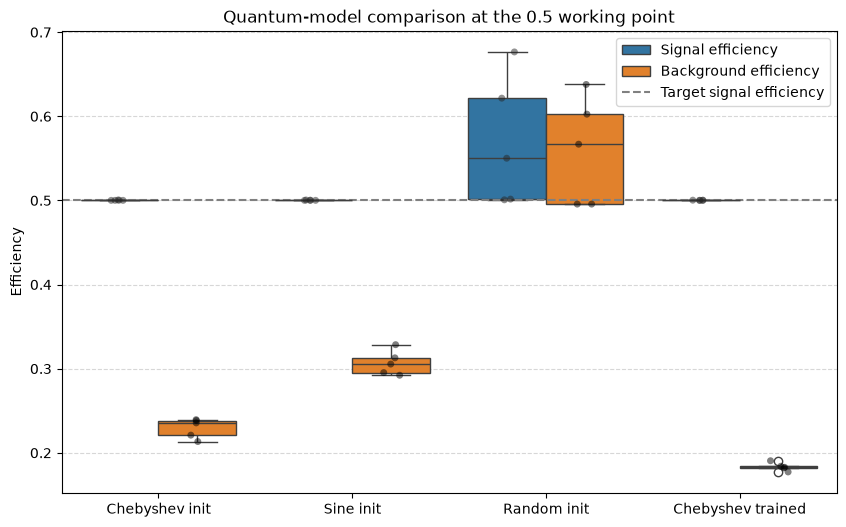

In [14]:
# Compare the quantum initializations at the 0.5 signal-efficiency working point
quantum_models = {
    "qkan_baseline_ideal": "Chebyshev init",
    "qkan_sine_baseline_ideal": "Sine init",
    "qkan_baseline_random_ideal": "Random init",
    "qkan_ideal": "Chebyshev trained",
}

efficiency_05 = df[df["model"].isin(quantum_models)].copy()
efficiency_05["Model"] = efficiency_05["model"].map(quantum_models)

summary_05 = (
    efficiency_05
    .groupby("Model")[
        [
            "Sig Eff 0.5 - Achieved Sig Eff",
            "Sig Eff 0.5 - Bkg Eff",
            "Sig Eff 0.5 - Bkg Rejection",
        ]
    ]
    .agg(["mean", "std"])
    .reindex(list(quantum_models.values()))
    .round(4)
)

display(summary_05)

plot_data = efficiency_05.melt(
    id_vars=["seed", "Model"],
    value_vars=[
        "Sig Eff 0.5 - Achieved Sig Eff",
        "Sig Eff 0.5 - Bkg Eff",
    ],
    var_name="Metric",
    value_name="Value",
)

plot_data["Metric"] = plot_data["Metric"].replace({
    "Sig Eff 0.5 - Achieved Sig Eff": "Signal efficiency",
    "Sig Eff 0.5 - Bkg Eff": "Background efficiency",
})

order = list(quantum_models.values())
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x="Model", y="Value", hue="Metric", order=order)
sns.stripplot(
    data=plot_data,
    x="Model",
    y="Value",
    hue="Metric",
    order=order,
    dodge=True,
    palette="dark:black",
    alpha=0.5,
    legend=False,
)
plt.axhline(0.5, color="gray", linestyle="--", label="Target signal efficiency")
plt.title("Quantum-model comparison at the 0.5 working point")
plt.ylabel("Efficiency")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

At the 0.5 signal-efficiency working point:

- The Chebyshev, sine, and trained models reach the target signal efficiency of 50%. The random initialization misses it ($0.57 \pm 0.08$), because its scores are almost constant and the threshold cannot be placed precisely.
- **Chebyshev init** has the best background rejection among the untrained circuits:
    - Background efficiency: **$0.230 \pm 0.012$**
    - Background rejection: **$4.37 \pm 0.23$**
- **Sine init** performs worse than Chebyshev and better than random:
    - Background efficiency: **$0.307 \pm 0.015$**
    - Background rejection: **$3.26 \pm 0.15$**
- **Random init** has the weakest separation:
    - Background efficiency: **$0.560 \pm 0.064$**
    - Background rejection: **$1.81 \pm 0.21$**
- After the quantum training, the **Chebyshev trained** circuit improves the rejection to **$5.46 \pm 0.14$** (background efficiency **$0.183 \pm 0.005$**).

The AUC shows the same ordering: random init $\approx 0.49$, sine init $\approx 0.64$, Chebyshev init $\approx 0.70$, and Chebyshev trained $\approx 0.74$.

We hypothesize that the scores of the random circuit are almost constant because the random rotations, followed by the entangling chain towards a single readout qubit, make $\langle Z \rangle$ depend only weakly on the input. With many nearly tied scores, a small change of the threshold moves a large block of events at once, and the achieved efficiency jumps past the target.

## Background rejection curves

The next plot shows the background rejection $1/\epsilon_{\mathrm{bkg}}$ as a function of the signal efficiency, averaged over the 5 seeds. It includes the classical references (Random Forest and KAN), the trained QKAN, and the three untrained initializations.

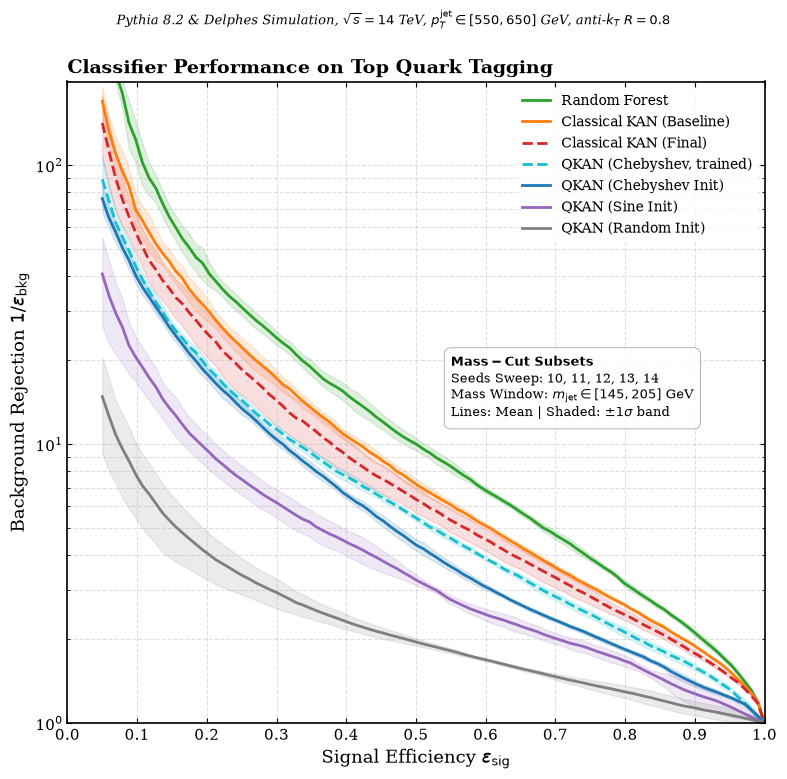

In [15]:
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "serif"
})

# Load the per-event eval data written by scripts/collect_eval_data.py
df_eval = pd.read_parquet(config["eval_table_path"])
df_eval = df_eval[df_eval["apply_mass_cut"] & (df_eval["n_subsets"] == 5)].reset_index(drop=True)

# Define our models to compare
models = {
    'random_forest': {'label': 'Random Forest', 'color': '#2ca02c', 'linestyle': '-'},
    'classical_base': {'label': 'Classical KAN (Baseline)', 'color': '#ff7f0e', 'linestyle': '-'},
    'classical_final': {'label': 'Classical KAN (Final)', 'color': '#d62728', 'linestyle': '--'},
    'qkan_ideal': {'label': 'QKAN (Chebyshev, trained)', 'color': '#17becf', 'linestyle': '--'},
    'qkan_baseline_ideal': {'label': 'QKAN (Chebyshev Init)', 'color': '#1f77b4', 'linestyle': '-'},
    'qkan_sine_baseline_ideal': {'label': 'QKAN (Sine Init)', 'color': '#9467bd', 'linestyle': '-'},
    'qkan_baseline_random_ideal': {'label': 'QKAN (Random Init)', 'color': '#7f7f7f', 'linestyle': '-'},
}

# Signal Efficiency grid for interpolation
grid_tpr = np.linspace(0.05, 1.0, 100)

plt.figure(figsize=(8, 8))
ax = plt.gca()

for m_id, m_info in models.items():
    m_df = df_eval[df_eval['model'] == m_id]
    rejs_matrix = []

    for _, row in m_df.iterrows():
        y_true = np.array(row['y_true'])
        y_probs = np.array(row['y_probs'])

        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_probs)

        # Interpolate Background Efficiency (FPR) onto common TPR grid
        interp_fpr = np.interp(grid_tpr, tpr, fpr)

        # Background Rejection is 1 / FPR
        rejection = 1.0 / np.maximum(interp_fpr, 1e-10)
        rejs_matrix.append(rejection)

    rejs_matrix = np.array(rejs_matrix)

    # Calculate statistics across seeds
    mean_rej = np.mean(rejs_matrix, axis=0)
    std_rej = np.std(rejs_matrix, axis=0)

    # Lower bound clipped at 1.0
    lower_band = np.maximum(mean_rej - std_rej, 1.0)
    upper_band = mean_rej + std_rej

    # Plot mean curve
    plt.plot(
        grid_tpr, mean_rej,
        color=m_info['color'],
        linestyle=m_info['linestyle'],
        linewidth=2.0,
        label=m_info['label']
    )

    # Plot standard deviation band
    plt.fill_between(
        grid_tpr, lower_band, upper_band,
        color=m_info['color'],
        alpha=0.15
    )

# Formatting the plot
plt.yscale('log')
plt.xlabel(r"Signal Efficiency $\epsilon_{\mathrm{sig}}$", fontsize=13)
plt.ylabel(r"Background Rejection $1 / \epsilon_{\mathrm{bkg}}$", fontsize=13)

# Show X axis with 0.1 increments
plt.xticks(np.arange(0., 1.1, 0.1))
plt.xlim(0., 1.)
plt.ylim(1.0, 200.0)

# Configure logarithmic major and minor ticks/grids
plt.grid(True, which="both", linestyle="--", alpha=0.4)

# Legend settings
plt.legend(frameon=True, facecolor="white", edgecolor="none", loc="upper right")

# Add descriptive metadata box
metadata_text = (
    r"$\mathbf{Mass-Cut\ Subsets}$" + "\n"
    r"Seeds Sweep: 10, 11, 12, 13, 14" + "\n"
    r"Mass Window: $m_{\mathrm{jet}} \in [145, 205]$ GeV" + "\n"
    r"Lines: Mean | Shaded: $\pm 1\sigma$ band"
)
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=0.5)
plt.text(
    0.55, 12.0, metadata_text,
    fontsize=9.5, transform=ax.transData, bbox=props, verticalalignment='bottom'
)

# Titles matching EDA_top design
plt.title("Classifier Performance on Top Quark Tagging", loc="left", fontweight="bold", fontsize=14)
plt.suptitle(
    r"Pythia 8.2 & Delphes Simulation, $\sqrt{s} = 14$ TeV, $p_T^{\mathrm{jet}} \in [550, 650]$ GeV, anti-$k_T$ $R=0.8$",
    fontsize=9.5, y=0.97, style="italic"
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

The curves keep the same ordering at every signal efficiency. The Random Forest dominates, the classic KAN stays close to it, and the trained QKAN sits between the classic KAN and its own Chebyshev initialization. The gap between the curves is largest at low signal efficiency, where the rejection is more sensitive to the tails of the score distributions. The random initialization stays close to $1/\epsilon_{\mathrm{bkg}} = 1/\epsilon_{\mathrm{sig}}$, the behavior of a random classifier.

A likely reason for the advantage of the Random Forest at low signal efficiency is that it also uses the angular distances of the leading constituents, which rank right after `m` and `n` in its feature importance (see **Selected features and circuit size**) and are removed by the pruning before the KAN retraining. The trained QKAN stays below the classic KAN for the reasons given after the AUC plot (same 2 inputs, approximate circuit mapping) and because it is undertrained (see **Training curves**).

## Background rejection at fixed working points

The metrics table also stores the background rejection at the signal efficiencies 0.3, 0.5, 0.7, and 0.9. The next plot shows the mean and the standard deviation over the seeds at these working points.

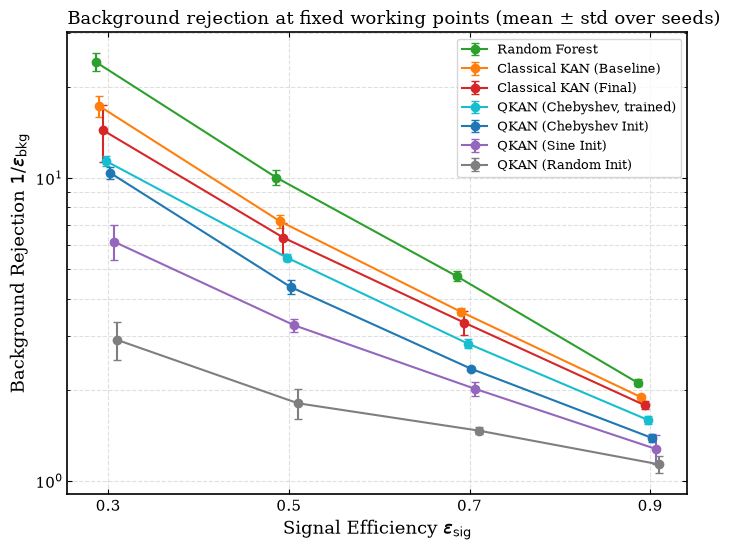

In [16]:
wp_models = [
    "random_forest", "classical_base", "classical_final", "qkan_ideal",
    "qkan_baseline_ideal", "qkan_sine_baseline_ideal", "qkan_baseline_random_ideal",
]
working_points = [0.3, 0.5, 0.7, 0.9]

fig, ax = plt.subplots(figsize=(8, 6))
for i, model in enumerate(wp_models):
    values = df.loc[df["model"] == model, [f"Sig Eff {wp} - Bkg Rejection" for wp in working_points]]
    offset = (i - len(wp_models) / 2) * 0.004  # small horizontal shift so the error bars do not overlap
    ax.errorbar(
        np.array(working_points) + offset, values.mean(), yerr=values.std(),
        marker="o", capsize=3, color=models[model]["color"], label=models[model]["label"],
    )
ax.set_yscale("log")
ax.set_xticks(working_points)
ax.set_xlabel(r"Signal Efficiency $\epsilon_{\mathrm{sig}}$")
ax.set_ylabel(r"Background Rejection $1 / \epsilon_{\mathrm{bkg}}$")
ax.set_title("Background rejection at fixed working points (mean ± std over seeds)", loc="left")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)
plt.show()

At $\epsilon_{\mathrm{sig}} = 0.3$ the Random Forest rejects about 24 background jets for each accepted one, the classic KAN (final) about 14, and the trained QKAN about 11. At $\epsilon_{\mathrm{sig}} = 0.9$ all models converge toward low rejections (2.11 for the Random Forest and 1.59 for the trained QKAN), since at high signal efficiency most of the background is also accepted.

The convergence at $\epsilon_{\mathrm{sig}} = 0.9$ is mostly geometric: keeping 90% of the signal requires accepting most of the background for every model. The large relative differences at $\epsilon_{\mathrm{sig}} = 0.3$ depend on the tails of the score distributions, where the extra features of the Random Forest give it more room to isolate a clean sample of top jets.

## Classical pipeline stages

The classic KAN goes through 4 evaluated stages: base, retrained after pruning, symbolic, and final (symbolic after fine-tuning). The next plot follows the test AUC of each seed across these stages, with the Random Forest as a reference.

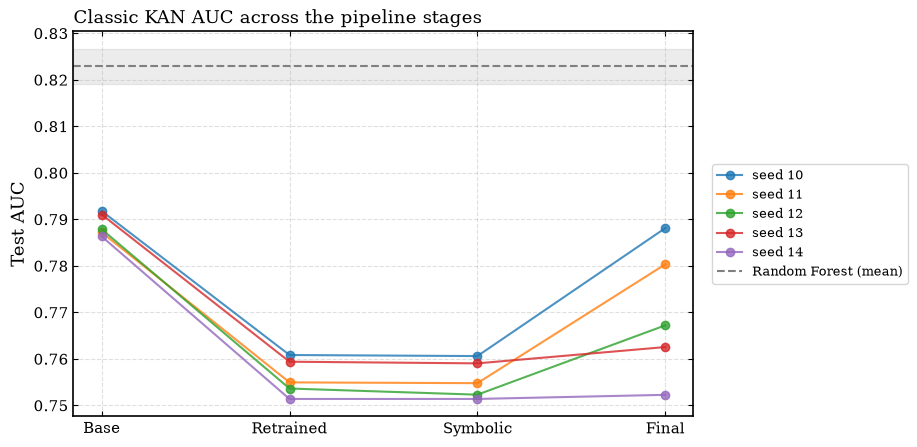

In [17]:
stages = ["classical_base", "classical_retrained", "classical_symbolic", "classical_final"]
stage_names = ["Base", "Retrained", "Symbolic", "Final"]

fig, ax = plt.subplots(figsize=(8, 5))
for seed in SEEDS:
    auc = df[df["seed"] == seed].set_index("model").loc[stages, "Test AUC"]
    ax.plot(range(len(stages)), auc.values, marker="o", alpha=0.8, label=f"seed {seed}")

rf_auc = df.loc[df["model"] == "random_forest", "Test AUC"]
ax.axhline(rf_auc.mean(), color="gray", linestyle="--", label="Random Forest (mean)")
ax.axhspan(rf_auc.mean() - rf_auc.std(), rf_auc.mean() + rf_auc.std(), color="gray", alpha=0.15)

ax.set_xticks(range(len(stages)), stage_names)
ax.set_ylabel("Test AUC")
ax.set_title("Classic KAN AUC across the pipeline stages", loc="left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

The pruning and retraining step costs about 0.03 in AUC (from 0.789 to 0.756). This is the price of reducing the network to a structure small enough for the quantum circuit. The symbolic fit alone keeps the AUC of the retrained model, which means that the fitted formulas reproduce the splines well. The final fine-tuning recovers part of the loss (0.770), with a larger spread between seeds, since the first epochs of the symbolic fine-tuning can be unstable (in seed 10 the first training loss reaches values of order $10^8$ before it settles).

**Possible causes.**
- The AUC drop after pruning matches the removal of the 20 per-particle features ($\Delta R_i$, $z_i$). The pruning thresholds that remove them are `node_th` and `edge_th`; the fan-in cap never activates at the production values (`reports/08_baseline_collapse_fixes_evaluation.md`, cause #3).
- The final model improves over the retrained one with the same 2 inputs. One hypothesis is that the retrained model stops before convergence, and the fine-tuning of the symbolic model works as additional training epochs on the same graph.
- The unstable start of the fine-tuning is consistent with symbolic functions that grow quickly outside the range where they were fitted (for example exponentials or high powers), which can produce very large activations in the first steps.

## Training curves

The eval table stores the training history of each run. The next plot shows the validation AUC and the validation loss per epoch for the classic KAN base training and for the QKAN training on the ideal simulator.

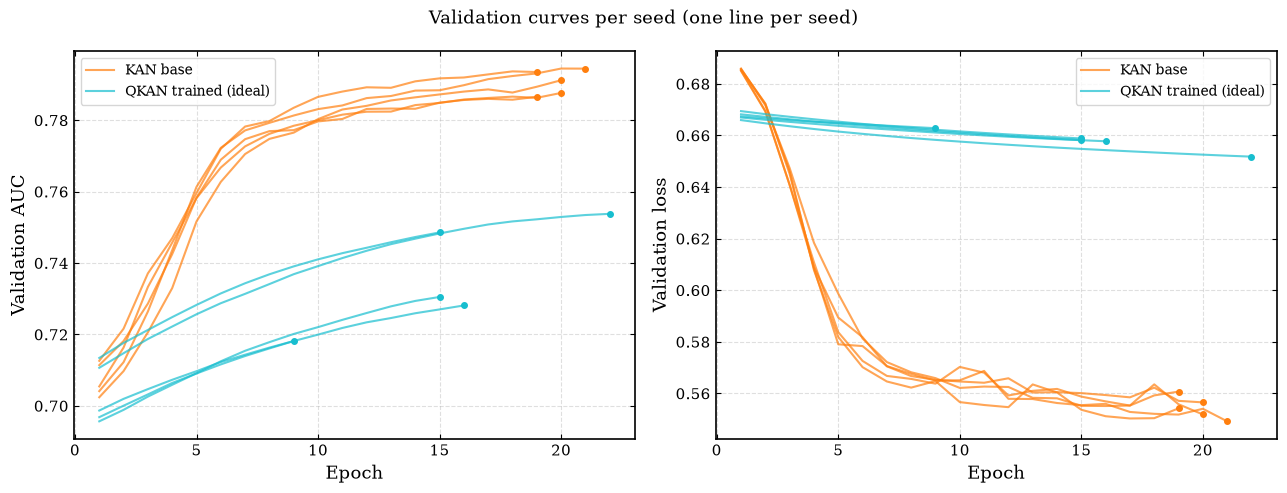

Epochs run by the QKAN per seed: [[10, 9], [11, 15], [12, 22], [13, 15], [14, 16]]


In [18]:
curve_models = {"classical_base": "#ff7f0e", "qkan_ideal": "#17becf"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for model, color in curve_models.items():
    for i, (_, row) in enumerate(df_eval[df_eval["model"] == model].iterrows()):
        epochs = np.arange(1, len(row["val_auc"]) + 1)
        label = MODEL_LABELS[model] if i == 0 else None
        axes[0].plot(epochs, row["val_auc"], color=color, alpha=0.7, label=label)
        axes[0].plot(epochs[-1], row["val_auc"][-1], marker="o", color=color, markersize=4, linestyle="None")
        axes[1].plot(epochs, row["val_loss"], color=color, alpha=0.7, label=label)
        axes[1].plot(epochs[-1], row["val_loss"][-1], marker="o", color=color, markersize=4, linestyle="None")

axes[0].set_ylabel("Validation AUC")
axes[1].set_ylabel("Validation loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
fig.suptitle("Validation curves per seed (one line per seed)")
plt.tight_layout()
plt.show()

print("Epochs run by the QKAN per seed:",
      df_eval.loc[df_eval["model"] == "qkan_ideal", ["seed", "n_epochs"]].astype(int).values.tolist())

The classic KAN converges in about 20 epochs, and its validation AUC reaches a plateau before the early stopping.

The QKAN behaves differently. Its validation AUC grows almost linearly, by about $0.003$ per epoch, and it is still increasing when the training stops (between 9 and 22 epochs out of a maximum of 50). Two details of the configuration explain this:
* Each epoch uses 1000 samples with a batch size of 1024, so each epoch is a single optimization step.
* The early stopping requires an improvement larger than $5 \times 10^{-3}$ in the validation loss or AUC, which is larger than the gain of a single step.

This indicates that the QKAN is undertrained, and that the reported QKAN metrics are a lower bound of what the circuit can reach with more optimization steps or a smaller early-stopping threshold.

The validation loss also moves very little (it stays around $0.66$, close to $\ln 2 \approx 0.693$) while the AUC grows. This is expected from the bounded output: with the logit in $[-1, 1]$, even a perfect classifier cannot bring the binary cross-entropy below $\ln(1 + e^{-1}) \approx 0.31$, and the circuit uses only part of that range. The loss is therefore a weak signal of progress, while the ranking of the events (AUC) can still improve. The gradients of the circuit are not vanishing (`reports/08_baseline_collapse_fixes_evaluation.md`, cause #4), so a barren plateau is an unlikely explanation for the slow training.

## Effect of the quantum training and the backend

Each QKAN is evaluated with its Chebyshev initialization before training and again after training, on the three backends (`ideal`, `shots`, and `noisy`). The next plot connects both evaluations for each seed.

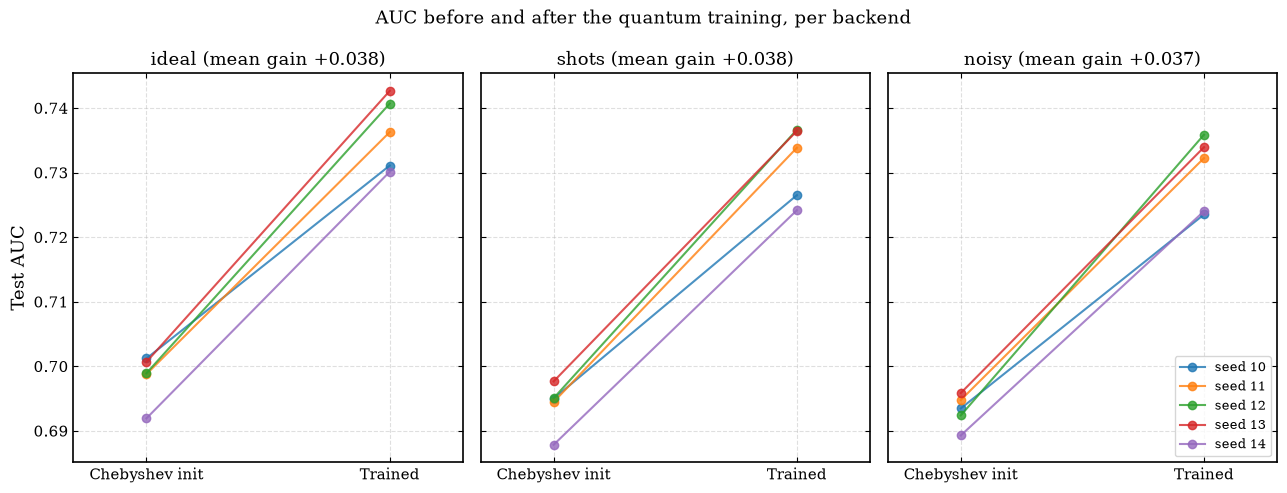

In [19]:
backends = ["ideal", "shots", "noisy"]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
for ax, backend in zip(axes, backends):
    pivot = df.pivot(index="seed", columns="model", values="Test AUC")
    before, after = pivot[f"qkan_baseline_{backend}"], pivot[f"qkan_{backend}"]
    for seed in SEEDS:
        ax.plot([0, 1], [before[seed], after[seed]], marker="o", alpha=0.8, label=f"seed {seed}")
    ax.set_xticks([0, 1], ["Chebyshev init", "Trained"])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f"{backend} (mean gain {np.mean(after - before):+.3f})")
    ax.grid(True, linestyle="--", alpha=0.4)
axes[0].set_ylabel("Test AUC")
axes[-1].legend(fontsize=9, loc="lower right")
fig.suptitle("AUC before and after the quantum training, per backend")
plt.tight_layout()
plt.show()

The quantum training improves the AUC in every seed and on every backend, by about 0.04 on average. The training runs on the ideal simulator, and the trained parameters transfer to the shot-based and noisy simulators with a small loss (the trained AUC is 0.736 on `ideal`, 0.732 on `shots`, and 0.730 on `noisy`). The noise model of `FakeManilaV2` describes a 5-qubit device, while the circuits use 10 or 11 qubits, so the noisy results should be read as an approximation of a real device.

**Why the backends barely change the AUC.**
- **Shots.** With 1024 shots, the statistical error of $\langle Z \rangle$ is about $\sqrt{1 - \langle Z \rangle^2}/32 \lesssim 0.03$, small compared with the spread of the scores, so only events that are already very close to each other change their order.
- **Noise.** A depolarizing-like noise pulls $\langle Z \rangle$ towards 0 in an approximately uniform way. If this contraction is monotonic, it compresses the probabilities towards 0.5 and keeps the order of the events, which would explain why the AUC changes so little. This is a hypothesis; the real noise model also contains readout and gate-specific errors.

## Output score distributions

The next plot compares the distribution of the predicted probabilities for signal and background jets, pooling the test events of the 5 seeds, for the final classic KAN and the trained QKAN.

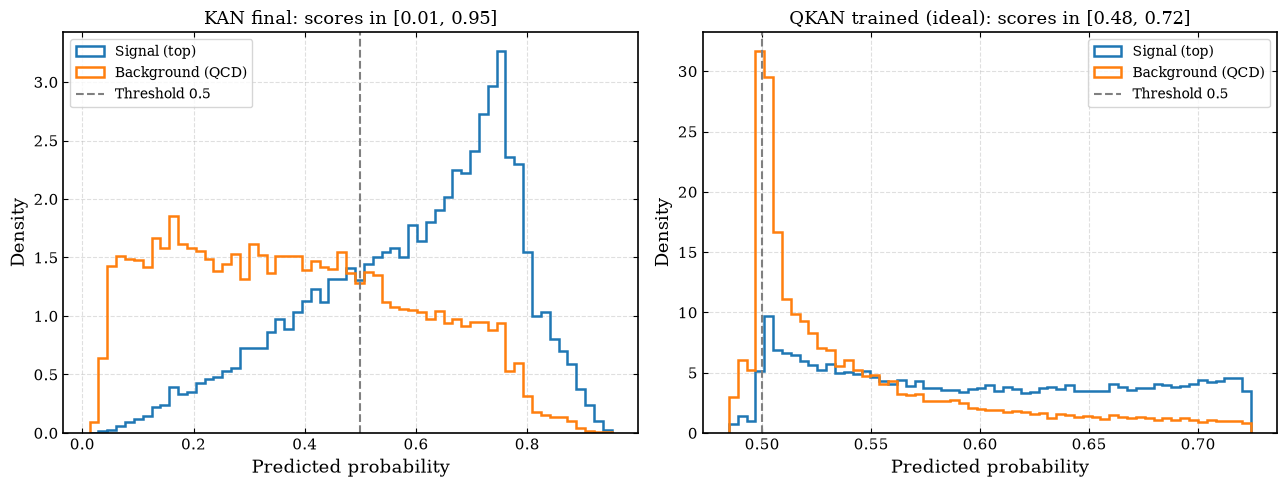

In [20]:
score_models = ["classical_final", "qkan_ideal"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model in zip(axes, score_models):
    rows = df_eval[df_eval["model"] == model]
    y_true = np.concatenate(rows["y_true"].values)
    y_probs = np.concatenate(rows["y_probs"].values)
    bins = np.linspace(y_probs.min(), y_probs.max(), 60)
    ax.hist(y_probs[y_true == 1], bins=bins, histtype="step", density=True, linewidth=1.8, label="Signal (top)")
    ax.hist(y_probs[y_true == 0], bins=bins, histtype="step", density=True, linewidth=1.8, label="Background (QCD)")
    ax.axvline(0.5, color="gray", linestyle="--", label="Threshold 0.5")
    ax.set_title(f"{MODEL_LABELS[model]}: scores in [{y_probs.min():.2f}, {y_probs.max():.2f}]")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
plt.tight_layout()
plt.show()

The classic KAN uses almost the whole $[0, 1]$ range. The QKAN output is the expectation value $\langle Z \rangle \in [-1, 1]$ used as a logit, so after the sigmoid the probabilities are restricted to a narrow interval, and in practice they stay in about $[0.48, 0.72]$. With the default threshold of 0.5, almost every event is classified as signal. This explains the high recall (about $0.97$) and the low accuracy (about $0.55$) of the QKAN models.

The ordering of the events is still informative, which is what the AUC and the background rejection measure. A threshold chosen on the validation set, or a scaling of $\langle Z \rangle$ before the sigmoid, would give an accuracy consistent with the AUC.

**Possible cause of the shift towards signal.** Every qubit starts in $|0\rangle$, where $\langle Z \rangle = +1$, and the Chebyshev coefficients are small rotation angles. We hypothesize that the output state stays close to $|0\rangle$ for most events, so $\langle Z \rangle$ is mostly positive and the probability is mostly above 0.5. The constant (degree 0) Chebyshev term does not seem to be responsible: setting it to zero changes the AUC by less than $0.003$ (`reports/08_baseline_collapse_fixes_evaluation.md`, cause #2).

## Mean confusion matrices

The next figure shows the confusion matrices normalized by the true class (each row sums to 1), with the mean and the standard deviation over the 5 seeds. Each seed has the same number of signal and background jets in its test set (4733 of each), so the rates of the different seeds are directly comparable.

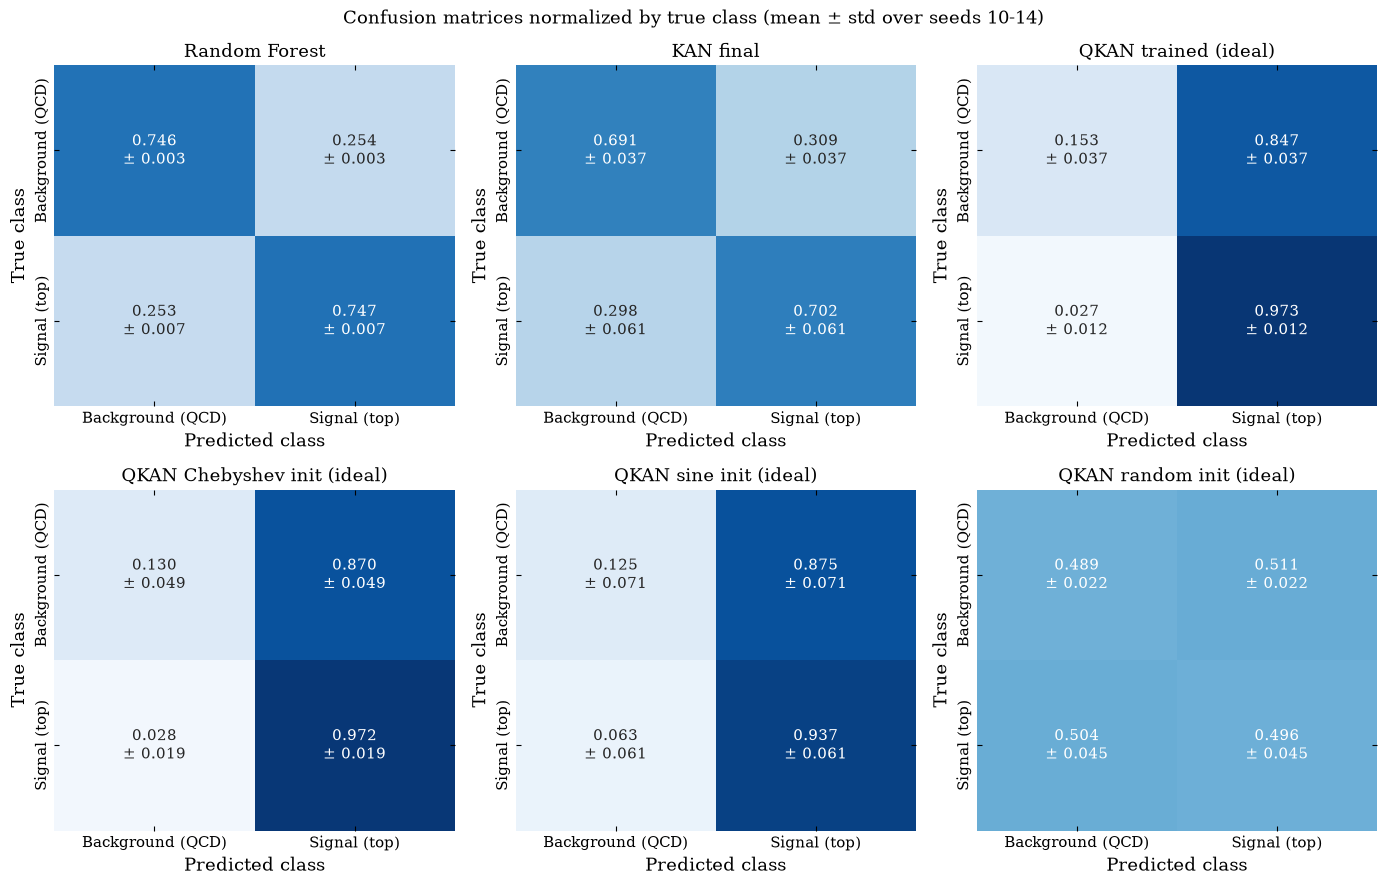

In [21]:
cm_models = [
    "random_forest", "classical_final", "qkan_ideal",
    "qkan_baseline_ideal", "qkan_sine_baseline_ideal", "qkan_baseline_random_ideal",
]
class_names = ["Background (QCD)", "Signal (top)"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, model in zip(axes.flat, cm_models):
    # [[TN, FP], [FN, TP]] per seed, normalized by the true class (rows)
    cms = np.array([json.loads(cm) for cm in df.loc[df["model"] == model, "Confusion Matrix"]], dtype=float)
    rates = cms / cms.sum(axis=2, keepdims=True)
    mean, std = rates.mean(axis=0), rates.std(axis=0, ddof=1)
    annot = np.array([[f"{mean[i, j]:.3f}\n± {std[i, j]:.3f}" for j in range(2)] for i in range(2)])
    sns.heatmap(mean, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
fig.suptitle("Confusion matrices normalized by true class (mean ± std over seeds 10-14)")
plt.tight_layout()
plt.show()

The matrices summarize several effects discussed in the previous sections:

- **Random Forest and classic KAN.** Both matrices are close to symmetric (about $0.75$ on the diagonal for the Random Forest and $0.69$ to $0.70$ for the final KAN), so the errors are balanced between the classes and the accuracy agrees with the AUC. The larger spread of the final KAN ($\pm 0.04$ to $\pm 0.06$) matches the seed-to-seed variability of the symbolic fine-tuning seen in **Classical pipeline stages**.
- **QKAN, with the Chebyshev or sine initialization and after training.** More than 97% of the top jets are classified correctly, but only 13% to 15% of the QCD jets. This is the shift towards positive $\langle Z \rangle$ described in **Output score distributions**. The training improves the true negative rate only slightly ($0.130 \to 0.153$), consistent with the nearly flat validation loss in **Training curves**: the training reorders the events (higher AUC) without moving most of them across the 0.5 threshold. The large standard deviation of the true negative rate suggests that a small change of the offset of $\langle Z \rangle$ between seeds moves many background events across the threshold at once, because most scores sit close to 0.5.
- **Random initialization.** All four entries are close to 0.5, the behavior of a random classifier, in agreement with the hypothesis tests of **Quantum initializations**.

On the shot-based and noisy backends the trained QKAN reaches a slightly higher true negative rate (about $0.19$ against $0.15$ on `ideal`). A pure contraction of $\langle Z \rangle$ towards 0 would keep every event on the same side of the threshold, so we attribute this change mainly to the shot noise: since most events sit just above 0.5, a symmetric fluctuation moves more of them below the threshold than above it.

A threshold chosen on the validation set would balance these matrices for the trained QKAN, since its scores carry signal. For a circuit without signal, the threshold cannot help: the optimal Youden threshold of a collapsed baseline circuit was $0.497$, almost identical to 0.5 (`reports/08_baseline_collapse_fixes_evaluation.md`, cause #1).

## Quality of the classical-to-quantum extraction

The extraction reports (`chebyshev_coefficients.txt` and `sine_coefficients.txt`) contain the $R^2$ of the fit of every edge. The next plot compares the distribution of these values for both bases across the 5 seeds.

,count,mean,std,min,25%,50%,75%,max
Basis,,,,,,,,
Chebyshev,110.0,0.9980,0.0018,0.9914,0.9972,0.9984,0.9994,0.9999
Sine,110.0,0.5581,0.5292,-0.6553,0.0286,0.8373,0.9708,0.9994


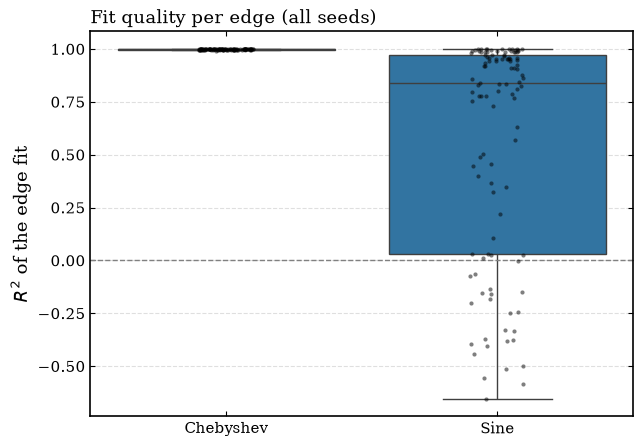

In [22]:
rows = []
for seed in SEEDS:
    results_dir = Path(get_config("top", seed)["results_dir"])
    for basis, file_name in [("Chebyshev", "chebyshev_coefficients.txt"), ("Sine", "sine_coefficients.txt")]:
        text = (results_dir / file_name).read_text()
        for r2 in re.findall(r"R2=(-?\d+\.\d+)", text):
            rows.append({"seed": seed, "Basis": basis, "R2": float(r2)})
r2_df = pd.DataFrame(rows)

display(r2_df.groupby("Basis")["R2"].describe().round(4))

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=r2_df, x="Basis", y="R2", ax=ax, showfliers=False)
sns.stripplot(data=r2_df, x="Basis", y="R2", ax=ax, color="black", size=3, alpha=0.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel(r"$R^2$ of the edge fit")
ax.set_xlabel("")
ax.set_title("Fit quality per edge (all seeds)", loc="left")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.show()

The Chebyshev basis of degree 4 reproduces the splines almost perfectly (median $R^2$ of 0.998), while the sine basis gives a median of 0.84 and several edges with negative $R^2$. This agrees with the lower AUC of the sine initialization and supports the use of the Chebyshev basis as the warm start of the circuit.

**Why the sine fit is worse.** Both bases are fitted by ordinary least squares, and the difference comes from the columns of each design matrix:
- The sine basis $\sum_k A_k \sin(\omega_k x + \varphi_k)$ has fixed frequencies and phases and **no constant column**, so the fit (`sinefit` in `src/architectures/sine_basis.py`) cannot represent a constant offset. Every edge carries such an offset, because the extractor gives each edge an equal share $y_{\mathrm{zero}}/n_{\mathrm{in}}$ of the constant term of its node (`src/architectures/extractor.py`). To approximate the offset, the least-squares solution distorts the amplitudes of the other terms, and the variable part of the edge is fitted worse.
- The $R^2$ is computed with respect to the mean of the edge response. Without an intercept, the fit can be worse than predicting that mean, which explains the negative values.
- The Chebyshev basis includes the constant term $T_0$ and is a polynomial basis well suited to smooth splines on $[-1, 1]$.

A related effect of least squares appears in the Chebyshev extraction: `chebfit` refits all the coefficients at each degree, so the fits are not nested, and truncating at a lower degree also changes the low-order coefficients. An earlier extraction that accepted the lowest degree passing an $R^2$ gate collapsed the AUC of the untrained circuit for this reason, and the fixed degree 4 used here solves it (`reports/01_qkan_baseline_auc_regression.md` and `reports/03_chebyshev_degree_floor_vs_fixed_degree.md`). Adding a constant term to the sine basis is the natural next step to test whether the gap with the Chebyshev initialization closes.

A high $R^2$ does not guarantee that the circuit reproduces the classic KAN: the Chebyshev initialization reaches an AUC of $0.70$ with a median $R^2$ of $0.998$, below the $0.756$ of the retrained KAN it comes from.

## Selected features and circuit size

The next table summarizes the quantum graph extracted in each seed: the number of qubits, the input features that reach the circuit, and the type of the hidden nodes.

In [23]:
rows = []
for seed in SEEDS:
    weights_dir = Path(get_config("top", seed)["polynomial_weights_dir"])
    graph = torch.load(weights_dir / "quantum_weights.pt", weights_only=False)
    node_types = [node["type"] for node in graph["hidden_nodes"]]
    rows.append({
        "seed": seed,
        "qubits": graph["n_qubits"],
        "inputs": ", ".join(TOTAL_FEATURES[i] for i in graph["active_inputs"]),
        "sum nodes": node_types.count("sum"),
        "mult nodes": node_types.count("mult"),
    })
pd.DataFrame(rows).set_index("seed")

,qubits,inputs,sum nodes,mult nodes
seed,,,,
10,11,"m, n",1,5
11,10,"m, n",0,5
12,10,"m, n",0,5
13,11,"m, n",1,5
14,11,"m, n",1,5


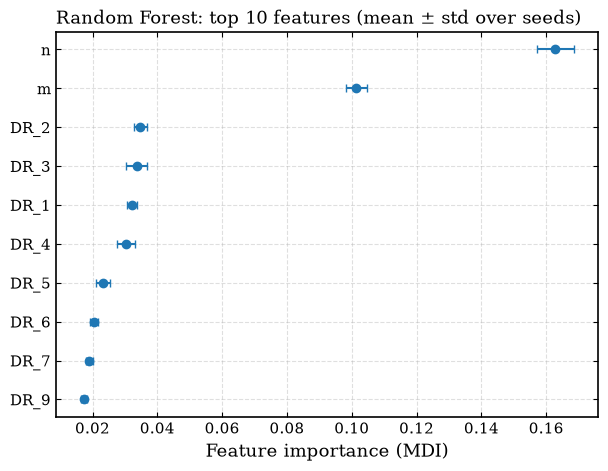

In [24]:
# Random Forest feature importance (MDI), mean and std over the seeds
importance = pd.DataFrame([
    pd.read_json(get_config("top", seed)["rf_feature_importance_data"], typ="series")
    for seed in SEEDS
])
top = importance.mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(top.values, range(len(top)), xerr=importance[top.index].std().values, fmt="o", capsize=3)
ax.set_yticks(range(len(top)), top.index)
ax.invert_yaxis()
ax.set_xlabel("Feature importance (MDI)")
ax.set_title("Random Forest: top 10 features (mean ± std over seeds)", loc="left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

In all 5 seeds, the quantum graph keeps only the jet mass `m` and the constituent multiplicity `n`, with 10 or 11 qubits and mostly multiplication nodes. The Random Forest, trained on the 22 features, ranks the same two variables first by a wide margin, followed by the angular distances of the leading constituents. Both methods agree on where most of the discriminating information is, which supports the use of the classic KAN pruning as a filter of the inputs of the circuit.

The number of qubits comes from the hidden nodes (one wire per group of edges), so even with only 2 inputs the circuit needs 10 or 11 qubits. Reducing the number of hidden nodes is therefore the main lever to reduce the size of the circuit.

The dominance of multiplication nodes suggests that the classic KAN finds the interaction between `m` and `n` more informative than their separate contributions; inside the mass window the mass alone separates the classes only weakly. This is a hypothesis based on the structure of the graph. Keeping more inputs requires looser pruning thresholds, and in a test on seed 12 this raised the circuit to 21 qubits, too many for the ideal and noisy simulators (`reports/08_baseline_collapse_fixes_evaluation.md`, cause #3).

## Computational cost

The next plot shows the time needed to evaluate the test set with each QKAN backend, before and after training.

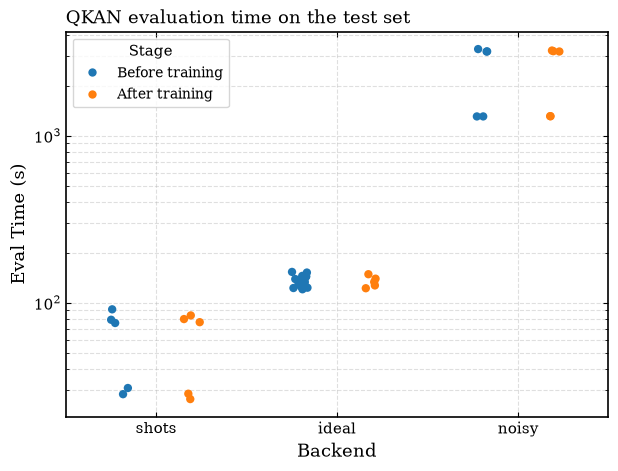

Mean classic KAN pipeline time (s): 379.3
Mean Random Forest pipeline time (s): 14.1


In [25]:
cost = df[df["model"].str.startswith("qkan_")].copy()
cost["Stage"] = np.where(cost["Baseline"].astype(bool), "Before training", "After training")

fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(data=cost, x="Backend", y="Eval Time (s)", hue="Stage", hue_order=["Before training", "After training"], order=["shots", "ideal", "noisy"], dodge=True, size=6, ax=ax)
ax.set_yscale("log")
ax.set_title("QKAN evaluation time on the test set", loc="left")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

print("Mean classic KAN pipeline time (s):", round(df.loc[df["model"] == "classical_final", "total_pipeline_time_seconds"].mean(), 1))
print("Mean Random Forest pipeline time (s):", round(df.loc[df["model"] == "random_forest", "total_pipeline_time_seconds"].mean(), 1))

The noisy density-matrix simulation is the most expensive step, with between about 1307 s and 3307 s per evaluation depending on the run, against about 135 s on the ideal simulator and between 27 s and 91 s with shots. For comparison, the whole classic KAN pipeline takes about 379 s and the Random Forest about 14 s. The cost of the density-matrix simulation grows as $4^Q$ with the number of qubits $Q$, which is one more reason to keep the circuit small.

The shot-based evaluation is faster than the ideal one, although both simulate the same state vector. The two backends use different simulators (`default.qubit` with 1024 shots and `lightning.qubit`), and we hypothesize that the difference comes from how each one executes the batched circuits; we did not profile this. The wide range of the noisy evaluation times probably reflects both the circuit size (10 or 11 qubits) and the load of the machine during each run.

## Conclusions

For the top-tagging task with the invariant mass cut ($145$ to $205$ GeV) and 5 disjoint subsets (seeds 10 to 14):

1. **Classical references.** The Random Forest reaches an AUC of $0.823 \pm 0.004$ and the classic KAN $0.789 \pm 0.002$ (base) and $0.770 \pm 0.014$ (final). The pruning needed to build the circuit costs about 0.03 in AUC.
2. **Warm start.** The Chebyshev initialization transfers a clear signal to the circuit before any quantum training (AUC 0.70), well above the sine (0.64) and random (0.49) initializations. The differences with the random initialization are significant after the Holm correction.
3. **Quantum training.** The training improves the AUC to 0.736 on the ideal simulator, and the result transfers to the shot-based (0.732) and noisy (0.730) simulators with a small loss. The validation curves show that the QKAN is still improving when the early stopping triggers, so these values are a lower bound.
4. **Selected inputs.** The circuit uses only `m` and `n`, the same two variables that the Random Forest ranks as the most important.
5. **Metrics.** The narrow output range of the circuit makes the accuracy at a threshold of 0.5 misleading for the QKAN models; the AUC and the background rejection give the fair comparison.

These conclusions should be interpreted cautiously because they are based on only five seeds.

6. **Main hypotheses behind the results.** The pruning to 2 inputs is the main limit of the QKAN, since the retrained KAN with the same inputs already sets its ceiling. The bounded output of the circuit, which starts close to $\langle Z \rangle = +1$, explains the low accuracy and the flat loss. The short training (a single optimization step per epoch) leaves the circuit undertrained. The sine initialization is limited by the lack of a constant term in its least-squares fit.